In [1]:
import numpy as np 
import pandas as pd
import os
from readData import *
from baryonFit import HernquistFit

import matplotlib.pyplot as plt

# Get all galaxy ids

In [2]:
galaxy_ids = get_galaxy_ids()

# Generate all lmfit fits assuming gamma = 0.5

In [21]:
plot_path = os.getcwd() + "/plots/fits/"
data_path = os.getcwd() + "/data/fit_data/"

results = []
failed = []

for galaxy_id in galaxy_ids:
    try:
        fitter = HernquistFit(galaxy_id, gamma_star=0.5, method="lmfit")
        M_b_fit, a_fit = fitter.M_b_fit, fitter.a_fit
        chisqr = fitter.result.chisqr
        redchisqr = fitter.result.redchi
    except Exception as e:
        failed.append(galaxy_id)
        print(f"Error fitting galaxy {galaxy_id}. Skipping...")
        continue
    
    results.append([galaxy_id, M_b_fit, a_fit, chisqr, redchisqr])
    
    rmax = fitter.r_vals.max() * 2 # kpc
    r_vals = np.geomspace(0.1, rmax, 100)
    vc_fit = fitter.vc(r_vals)
    
    plt.figure(figsize=(6,4))
    plt.plot(r_vals, vc_fit, label='Hernquist Fit', color='C0', alpha=0.7, zorder=0)
    plt.errorbar(fitter.r_vals, fitter.vc_baryons, yerr=fitter.data["errV"], fmt='o', label='Data', color='k', zorder=1, markersize=4, alpha=0.5)
    plt.xlabel('Radius [kpc]')
    plt.ylabel('Circular Velocity [km/s]')
    plt.title(f'Galaxy {galaxy_id} Hernquist Fit')
    plt.legend()
    plt.savefig(os.path.join(plot_path, f"{galaxy_id}_hernquist_fit.png"))
    plt.close()
    
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "M_b_fit", "a_fit", "ChiSq", "RedChiSq"])
results_df.to_csv(os.path.join(data_path, "hernquist_fit_results.csv"), index=False)
print("Fitting complete. Results saved.")
np.savetxt(os.path.join(data_path, "failed_fits.txt"), failed, fmt="%s")
    

Fitting with lmfit took 0.0110 seconds
Fitted parameters for galaxy NGC5371 using lmfit:
  M_b = 3.93e+11 solar masses
  a   = 10.53 kpc
  chi-squared = 6127.4849


Fitting with lmfit took 0.3429 seconds
Fitted parameters for galaxy UGC05829 using lmfit:
  M_b = 1.13e+21 solar masses
  a   = 5497424.38 kpc
  chi-squared = 185.9626
Fitting with lmfit took 0.0151 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 1.48e+11 solar masses
  a   = 2.37 kpc
  chi-squared = 2086.7819
Error fitting galaxy UGCA444 with lmfit: The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on parameters where applicable. In cases like this, using "nan_policy='omit'" will probably not work.
Fitting with lmfit took 0.0034 seconds
Error fitting galaxy UGCA444. Skipping...
Fitting with lmfit took 0.0068 seconds
Fitted parameters for galaxy NGC1003 using lmfit:
  M_b = 1.22e+10 solar masses
  a   = 4.40 kpc
  chi-squared = 264.3338
Error fitting galaxy UGC07559 with lmfit: The model function generated NaN values and the fit aborted! Please check your model function and/or set boundaries on paramete

# Plot the chi squared results

Number of galaxies with failed fits: 47


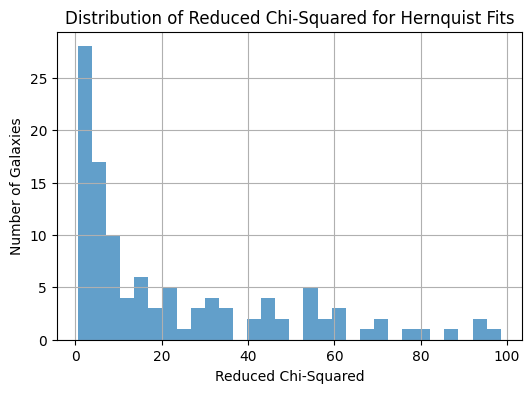

In [7]:
plot_path = os.getcwd() + "/plots/fits/"
data_path = os.getcwd() + "/data/fit_data/"

data = pd.read_csv(os.path.join(data_path, "hernquist_fit_results.csv"))
failed = np.loadtxt(os.path.join(data_path, "failed_fits.txt"), dtype=str).tolist()
print("Number of galaxies with failed fits:", len(failed))

sub = data[data["RedChiSq"] < 100]

plt.figure(figsize=(6,4))
plt.hist(sub["RedChiSq"], bins=30, color='C0', alpha=0.7)  
plt.xlabel('Reduced Chi-Squared')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Reduced Chi-Squared for Hernquist Fits')
plt.grid()
plt.show()

In [10]:
sub = data[data["RedChiSq"] < 10]
len(sub["GalaxyID"])

54

In [13]:
data[data["RedChiSq"] < 1]["GalaxyID"]

35     UGC06818
50       F563-1
64     UGC04499
75     UGC12632
77      NGC5585
117    UGC06628
Name: GalaxyID, dtype: object

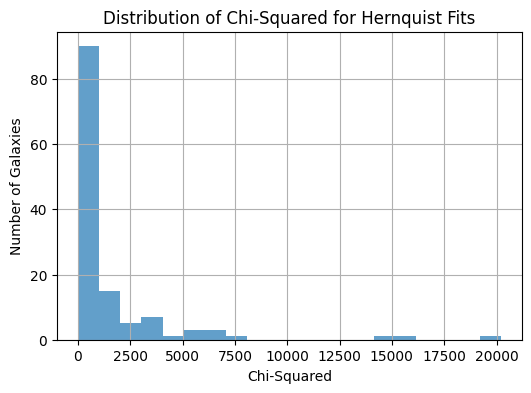

In [24]:
plt.figure(figsize=(6,4))
plt.hist(data["ChiSq"], bins=20, color='C0', alpha=0.7)  
plt.xlabel('Chi-Squared')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Chi-Squared for Hernquist Fits')
plt.grid()
plt.show()

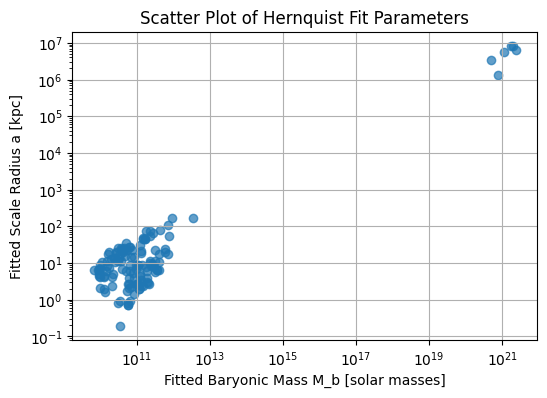

In [27]:
# scatter of M_b and a fits

plt.figure(figsize=(6,4))
plt.scatter(data["M_b_fit"], data["a_fit"], color='C0', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Fitted Baryonic Mass M_b [solar masses]')
plt.ylabel('Fitted Scale Radius a [kpc]')
plt.title('Scatter Plot of Hernquist Fit Parameters')
plt.grid()
plt.show()

# Mass-to-Light Ratio 

In [3]:
path = os.getcwd() + "/data/fit_data/"

results = []

for galaxy_id in galaxy_ids:
    g_disk, e_disk = Gamma_disk(galaxy_id)
    g_bulg, e_bulg = Gamma_bulge(galaxy_id)
    
    results.append([galaxy_id, g_disk, e_disk, g_bulg, e_bulg])
    
results_df = pd.DataFrame(results, columns=["GalaxyID", "Gamma_disk", "Error_disk", "Gamma_bulge", "Error_bulge"])
results_df.to_csv(os.path.join(path, "gamma_fits.csv"), index=False)

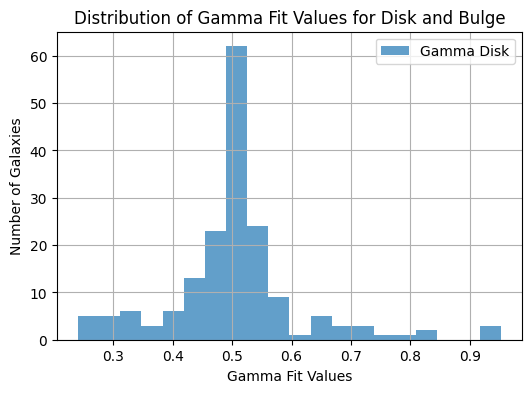

In [4]:
data = pd.read_csv(os.path.join(path, "gamma_fits.csv"))

plt.figure(figsize=(6,4))
plt.hist(data["Gamma_disk"], bins=20, color='C0', alpha=0.7)
# plt.hist(data["Gamma_bulge"], bins=30, color='C1', alpha=0.7)
plt.xlabel('Gamma Fit Values')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Gamma Fit Values for Disk and Bulge')
plt.legend(['Gamma Disk', 'Gamma Bulge'])
plt.grid()
plt.show()

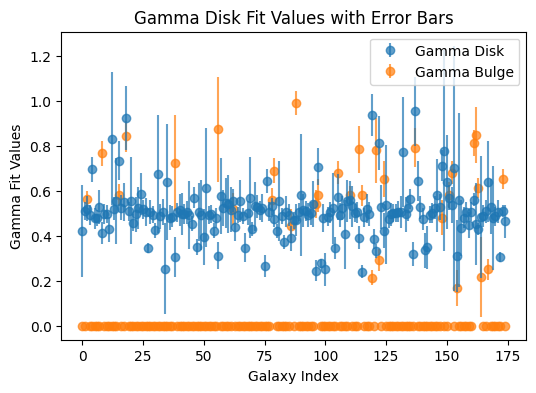

In [5]:
plt.figure(figsize=(6,4))

plt.errorbar(data["GalaxyID"].index, data["Gamma_disk"], yerr=data["Error_disk"], fmt='o', label='Gamma Disk', color='C0', alpha=0.7, zorder=3)
plt.errorbar(data["GalaxyID"].index, data["Gamma_bulge"], yerr=data["Error_bulge"], fmt='o', label='Gamma Bulge', color='C1', alpha=0.7, zorder=0)
plt.ylabel('Gamma Fit Values')
plt.xlabel('Galaxy Index')
plt.title('Gamma Disk Fit Values with Error Bars')
plt.legend()
plt.show()